# All Sites Forcing Data Figure 

created by Cassie Lumbrazo\
last updated: Sept 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# HRRR-AK Lapse-rate Files 
ds_snowpack_hrrrak_lapserate_ppsa, header_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_tram, header_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_lapserate_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate_heen, header_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_lapserate_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now
ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

# Met HRRR-AK Lapse-rate Files
# ds_snowpack_met_hrrrak_lapserate_ppsa, header_met_hrrrak_lapserate_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
# ds_snowpack_met_hrrrak_lapserate_tram, header_met_hrrrak_lapserate_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_lapserate_tram_WY2023-WY2025_base.smet")
# ds_snowpack_met_hrrrak_lapserate_heen, header_met_hrrrak_lapserate_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_lapserate_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025


# selecting the same time period for all datasets to make plotting easier
ds_snowpack_hrrrak_ppsa = ds_snowpack_hrrrak_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_tram = ds_snowpack_hrrrak_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_heen = ds_snowpack_hrrrak_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

ds_snowpack_hrrrak_lapserate_ppsa = ds_snowpack_hrrrak_lapserate_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_lapserate_tram = ds_snowpack_hrrrak_lapserate_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_hrrrak_lapserate_heen = ds_snowpack_hrrrak_lapserate_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

ds_snowpack_met_hrrrak_ppsa = ds_snowpack_met_hrrrak_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_met_hrrrak_tram = ds_snowpack_met_hrrrak_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
ds_snowpack_met_hrrrak_heen = ds_snowpack_met_hrrrak_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

# ds_snowpack_met_hrrrak_lapserate_ppsa = ds_snowpack_met_hrrrak_lapserate_ppsa.sel(timestamp=slice("2022-10-01", "2025-09-30"))
# ds_snowpack_met_hrrrak_lapserate_tram = ds_snowpack_met_hrrrak_lapserate_tram.sel(timestamp=slice("2022-10-01", "2025-09-30"))
# ds_snowpack_met_hrrrak_lapserate_heen = ds_snowpack_met_hrrrak_lapserate_heen.sel(timestamp=slice("2019-10-01", "2022-09-30"))

/tmp/ipykernel_1433203/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_1433203/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1433203/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1433203/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1433203/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1433203/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df 

### Open Observations

In [5]:
# open observations
#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))

# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

# selecting the same time period for all datasets to make plotting easier
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2022-10-01", "2025-09-30"))
ds_obs_tram = ds_obs_tram.sel(time=slice("2022-10-01", "2025-09-30"))
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2022-09-30"))

# HEEN obs temp is in K, convert to C 
ds_obs_heen["temp"] = ds_obs_heen["temp"] - 273.15

### Open HRRR-AK Data

In [6]:
# OPEN HRRR-AK NETCDF FILES
# PPSA
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_ppsa.nc"
ds_hrrr_ppsa = xr.open_dataset(input_file)
ds_hrrr_ppsa.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds_hrrr_ppsa = ds_hrrr_ppsa.sel(time=slice("2022-10-01", "2025-09-30"))
ds_hrrr_ppsa['precip_accum_1hr'] = ds_hrrr_ppsa['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data
ds_hrrr_ppsa['temp'] = ds_hrrr_ppsa['temp'] - 273.15 # convert from K to C for comparison with the observed data

# TRAM
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc"
ds_hrrr_tram = xr.open_dataset(input_file)
ds_hrrr_tram.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds_hrrr_tram = ds_hrrr_tram.sel(time=slice("2022-10-01", "2025-09-30"))
ds_hrrr_tram['precip_accum_1hr'] = ds_hrrr_tram['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data
ds_hrrr_tram['temp'] = ds_hrrr_tram['temp'] - 273.15 # convert from K to C for comparison with the observed data

# HEEN
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc"
ds_hrrr_heen = xr.open_dataset(input_file)
ds_hrrr_heen.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds_hrrr_heen = ds_hrrr_heen.sel(time=slice("2019-10-01", "2022-09-30"))
ds_hrrr_heen['precip_accum_1hr'] = ds_hrrr_heen['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data
ds_hrrr_heen['temp'] = ds_hrrr_heen['temp'] - 273.15 # convert from K to C for comparison with the observed data

### Plotting Constants 

In [7]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

In [8]:
ds_obs_heen

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 23506)
Coordinates:
  * time              (time) datetime64[ns] 188kB 2019-10-01 ... 2022-09-30T2...
Data variables:
    swe               (time) float64 188kB ...
    temp              (time) float64 188kB 6.6 6.9 7.1 7.4 ... nan nan nan nan
    hs                (time) float64 188kB ...
    rh                (time) float64 188kB ...
    precip_accum      (time) float64 188kB ...
    wind              (time) float64 188kB ...
    wind_dir          (time) float64 188kB ...
    pressure          (time) float64 188kB ...
    precip_rate       (time) float64 188kB ...
    precip_accum_1hr  (time) float64 188kB ...

# Recalc Lapserate Here

In [9]:
import copy

# =============================================================================
# CREATE HRRR-AK LAPSE-RATE-CORRECTED DATASETS
# =============================================================================

# Environmental lapse rate:
# Temperature decreases by 6.5 °C per 1000 m increase in elevation.
lapse_rate_c_per_m = -6.5 / 1000.0

# -----------------------------------------------------------------------------
# Site and HRRR-AK grid elevations
# -----------------------------------------------------------------------------

elevations = {
    "PPSA": {
        "site_elevation_m": 669.9,
        "hrrr_elevation_m": 585.55,
    },
    "TRAM": {
        "site_elevation_m": 529.1,
        "hrrr_elevation_m": 637.39,
    },
    "HEEN": {
        "site_elevation_m": 548.0,
        "hrrr_elevation_m": 743.61,
    },
}

# -----------------------------------------------------------------------------
# Function to apply the elevation-based temperature correction
# -----------------------------------------------------------------------------

def create_lapserate_dataset(
    ds_hrrr,
    site_elevation_m,
    hrrr_elevation_m,
    lapse_rate_c_per_m=-6.5 / 1000.0,
):
    """
    Return a copy of an HRRR-AK dataset with air temperature corrected
    from the HRRR grid elevation to the site elevation.

    Correction:
        T_site = T_hrrr + lapse_rate * (z_site - z_hrrr)

    Parameters
    ----------
    ds_hrrr : xarray.Dataset
        Raw HRRR-AK dataset containing a variable named 'temp'.

    site_elevation_m : float
        Meteorological station elevation in meters.

    hrrr_elevation_m : float
        Elevation of the corresponding HRRR-AK grid cell in meters.

    lapse_rate_c_per_m : float
        Temperature lapse rate in °C m-1. Default is -0.0065 °C m-1.

    Returns
    -------
    xarray.Dataset
        Copy of the original dataset with lapse-rate-corrected temperature.
        All other variables remain unchanged.
    """

    ds_lapserate = ds_hrrr.copy(deep=True)

    elevation_difference_m = site_elevation_m - hrrr_elevation_m

    temperature_correction = (
        lapse_rate_c_per_m * elevation_difference_m
    )

    ds_lapserate["temp"] = (
        ds_hrrr["temp"] + temperature_correction
    )

    # Preserve and document variable attributes
    ds_lapserate["temp"].attrs = ds_hrrr["temp"].attrs.copy()

    ds_lapserate["temp"].attrs["lapse_rate_correction"] = (
        f"{temperature_correction:+.3f} °C"
    )

    ds_lapserate["temp"].attrs["lapse_rate"] = (
        f"{lapse_rate_c_per_m * 1000:.2f} °C km-1"
    )

    ds_lapserate["temp"].attrs["site_elevation_m"] = (
        site_elevation_m
    )

    ds_lapserate["temp"].attrs["hrrr_grid_elevation_m"] = (
        hrrr_elevation_m
    )

    return ds_lapserate


# -----------------------------------------------------------------------------
# Create corrected datasets
# -----------------------------------------------------------------------------

ds_hrrr_lapserate_ppsa = create_lapserate_dataset(
    ds_hrrr=ds_hrrr_ppsa,
    site_elevation_m=elevations["PPSA"]["site_elevation_m"],
    hrrr_elevation_m=elevations["PPSA"]["hrrr_elevation_m"],
    lapse_rate_c_per_m=lapse_rate_c_per_m,
)

ds_hrrr_lapserate_tram = create_lapserate_dataset(
    ds_hrrr=ds_hrrr_tram,
    site_elevation_m=elevations["TRAM"]["site_elevation_m"],
    hrrr_elevation_m=elevations["TRAM"]["hrrr_elevation_m"],
    lapse_rate_c_per_m=lapse_rate_c_per_m,
)

ds_hrrr_lapserate_heen = create_lapserate_dataset(
    ds_hrrr=ds_hrrr_heen,
    site_elevation_m=elevations["HEEN"]["site_elevation_m"],
    hrrr_elevation_m=elevations["HEEN"]["hrrr_elevation_m"],
    lapse_rate_c_per_m=lapse_rate_c_per_m,
)

# -----------------------------------------------------------------------------
# Print applied corrections for verification
# -----------------------------------------------------------------------------

for site, values in elevations.items():

    elevation_difference = (
        values["site_elevation_m"]
        - values["hrrr_elevation_m"]
    )

    correction = (
        lapse_rate_c_per_m * elevation_difference
    )

    print(
        f"{site}: "
        f"site minus HRRR elevation = {elevation_difference:+.2f} m; "
        f"temperature correction = {correction:+.3f} °C"
    )

PPSA: site minus HRRR elevation = +84.35 m; temperature correction = -0.548 °C
TRAM: site minus HRRR elevation = -108.29 m; temperature correction = +0.704 °C
HEEN: site minus HRRR elevation = -195.61 m; temperature correction = +1.271 °C


# Updated Figure

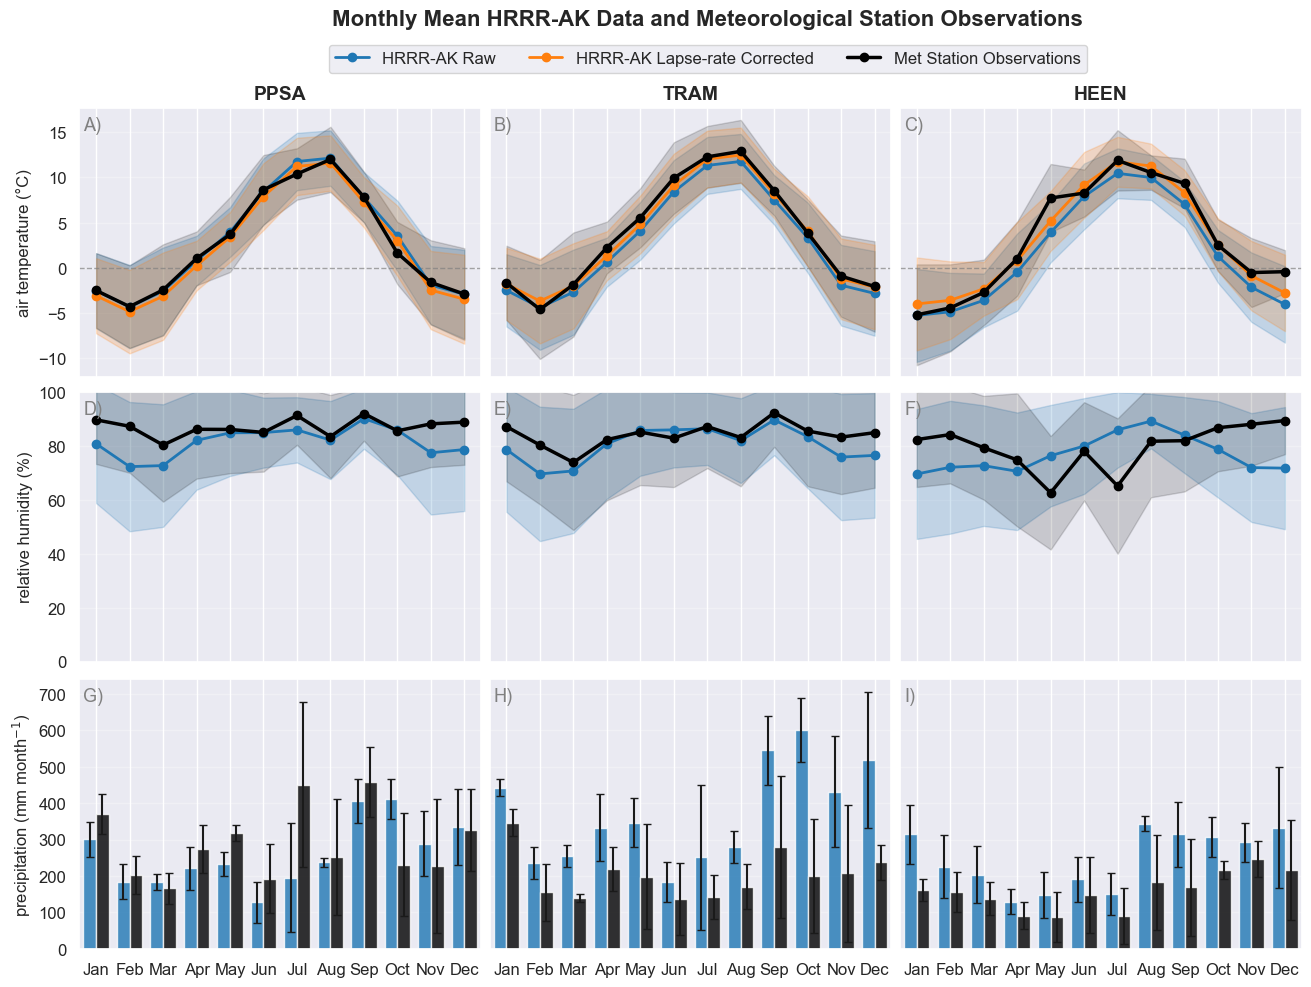

In [10]:
# =============================================================================
# PRECIPITATION DISPLAY OPTION
# =============================================================================

# 'hourly_mean'   = mean hourly precipitation rate for each month
# 'monthly_total' = mean monthly accumulated precipitation climatology

precip_mode = 'monthly_total'
# precip_mode = 'hourly_mean'


import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# USER SETTINGS
# =============================================================================

fontsize = 12

hrrrak_color = 'tab:blue'
hrrrak_lapserate_color = 'tab:orange'
obs_color = 'black'

linewidth_hrrr = 2
linewidth_hrrr_lapserate = 2
linewidth_obs = 2.5

alpha_hrrr = 0.20
alpha_hrrr_lapserate = 0.20
alpha_obs = 0.15

figsize = (13, 9)

# =============================================================================
# DATASETS
# =============================================================================

hrrr_datasets = {
    'PPSA': ds_hrrr_ppsa,
    'TRAM': ds_hrrr_tram,
    'HEEN': ds_hrrr_heen
}

hrrr_lapserate_datasets = {
    'PPSA': ds_hrrr_lapserate_ppsa,
    'TRAM': ds_hrrr_lapserate_tram,
    'HEEN': ds_hrrr_lapserate_heen
}

obs_datasets = {
    'PPSA': ds_obs_ppsa,
    'TRAM': ds_obs_tram,
    'HEEN': ds_obs_heen
}

site_names = ['PPSA', 'TRAM', 'HEEN']

var_names = [
    'temp',
    'rh',
    'precip_accum_1hr'
]

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

letters = list('ABCDEFGHI')

# =============================================================================
# VARIABLE LABELS
# =============================================================================

if precip_mode == 'monthly_total':
    precip_label = 'precipitation (mm month$^{-1}$)'
else:
    precip_label = 'precipitation (mm hr$^{-1}$)'

var_labels = {
    'temp': 'air temperature (°C)',
    'rh': 'relative humidity (%)',
    'precip_accum_1hr': precip_label
}

# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=figsize,
    sharex=True,
    sharey='row',
    constrained_layout=True
)

# =============================================================================
# LOOP THROUGH SITES AND VARIABLES
# =============================================================================

for col, site in enumerate(site_names):

    ds_hrrr = hrrr_datasets[site]
    ds_hrrr_lapserate = hrrr_lapserate_datasets[site]
    ds_obs = obs_datasets[site]

    for row, var in enumerate(var_names):

        ax = axes[row, col]

        # ----------------------------------------------------------
        # Add a 0 °C reference line
        # ----------------------------------------------------------

        if var == 'temp':

            ax.axhline(
                0,
                color='gray',
                lw=1,
                ls='--',
                alpha=0.7
            )

        # ==========================================================
        # TEMPERATURE AND RELATIVE HUMIDITY CLIMATOLOGY
        # ==========================================================

        if var != 'precip_accum_1hr':

            # Raw HRRR-AK
            hrrr_mean = (
                ds_hrrr[var]
                .groupby('time.month')
                .mean(skipna=True)
            )

            hrrr_std = (
                ds_hrrr[var]
                .groupby('time.month')
                .std(skipna=True)
            )

            # Observations
            obs_mean = (
                ds_obs[var]
                .groupby('time.month')
                .mean(skipna=True)
            )

            obs_std = (
                ds_obs[var]
                .groupby('time.month')
                .std(skipna=True)
            )

            # Lapse-rate correction only applies to temperature
            if var == 'temp':

                hrrr_lapserate_mean = (
                    ds_hrrr_lapserate[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_lapserate_std = (
                    ds_hrrr_lapserate[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

        # ==========================================================
        # PRECIPITATION CLIMATOLOGY
        # ==========================================================

        else:

            # ------------------------------------------------------
            # Mean hourly precipitation rate
            # ------------------------------------------------------

            if precip_mode == 'hourly_mean':

                hrrr_mean = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

                obs_mean = (
                    ds_obs[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                obs_std = (
                    ds_obs[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

            # ------------------------------------------------------
            # Monthly accumulated precipitation climatology
            # ------------------------------------------------------

            elif precip_mode == 'monthly_total':

                # HRRR-AK monthly totals
                hrrr_monthly = (
                    ds_hrrr[var]
                    .resample(time='MS')
                    .sum(skipna=True)
                )

                hrrr_coverage = (
                    ds_hrrr[var]
                    .notnull()
                    .resample(time='MS')
                    .mean()
                )

                hrrr_monthly = hrrr_monthly.where(
                    hrrr_coverage >= 0.90
                )

                hrrr_mean = (
                    hrrr_monthly
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    hrrr_monthly
                    .groupby('time.month')
                    .std(skipna=True)
                )

                # Observation monthly totals
                obs_monthly = (
                    ds_obs[var]
                    .resample(time='MS')
                    .sum(skipna=True)
                )

                obs_coverage = (
                    ds_obs[var]
                    .notnull()
                    .resample(time='MS')
                    .mean()
                )

                obs_monthly = obs_monthly.where(
                    obs_coverage >= 0.90
                )

                obs_mean = (
                    obs_monthly
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                obs_std = (
                    obs_monthly
                    .groupby('time.month')
                    .std(skipna=True)
                )

            else:

                raise ValueError(
                    "precip_mode must be "
                    "'hourly_mean' or 'monthly_total'"
                )

        # ==========================================================
        # TEMPERATURE AND RELATIVE HUMIDITY PLOTS
        # ==========================================================

        if var != 'precip_accum_1hr':

            # Raw HRRR-AK uncertainty
            ax.fill_between(
                hrrr_mean.month,
                hrrr_mean - hrrr_std,
                hrrr_mean + hrrr_std,
                color=hrrrak_color,
                alpha=alpha_hrrr
            )

            # Observation uncertainty
            ax.fill_between(
                obs_mean.month,
                obs_mean - obs_std,
                obs_mean + obs_std,
                color=obs_color,
                alpha=alpha_obs
            )

            # Raw HRRR-AK mean
            ax.plot(
                hrrr_mean.month,
                hrrr_mean,
                color=hrrrak_color,
                lw=linewidth_hrrr,
                marker='o',
                label='HRRR-AK Raw'
            )

            # ------------------------------------------------------
            # Lapse-rate-corrected temperature
            # ------------------------------------------------------

            if var == 'temp':

                ax.fill_between(
                    hrrr_lapserate_mean.month,
                    hrrr_lapserate_mean - hrrr_lapserate_std,
                    hrrr_lapserate_mean + hrrr_lapserate_std,
                    color=hrrrak_lapserate_color,
                    alpha=alpha_hrrr_lapserate
                )

                ax.plot(
                    hrrr_lapserate_mean.month,
                    hrrr_lapserate_mean,
                    color=hrrrak_lapserate_color,
                    lw=linewidth_hrrr_lapserate,
                    marker='o',
                    label='HRRR-AK Lapse-rate Corrected'
                )

            # Observed mean
            ax.plot(
                obs_mean.month,
                obs_mean,
                color=obs_color,
                lw=linewidth_obs,
                marker='o',
                label='Met Station Observations'
            )

        # ==========================================================
        # PRECIPITATION PLOTS
        # ==========================================================

        else:

            months = np.arange(1, 13)
            width = 0.38

            ax.bar(
                months - width / 2,
                hrrr_mean,
                width,
                color=hrrrak_color,
                alpha=0.8,
                yerr=hrrr_std,
                capsize=3,
                label='HRRR-AK Raw'
            )

            ax.bar(
                months + width / 2,
                obs_mean,
                width,
                color=obs_color,
                alpha=0.8,
                yerr=obs_std,
                capsize=3,
                label='Met Station Observations'
            )

        # ==========================================================
        # AXIS FORMATTING
        # ==========================================================

        ax.set_xlim(0.5, 12.5)

        ax.set_xticks(np.arange(1, 13))
        ax.set_xticklabels(month_labels)

        ax.tick_params(
            axis='both',
            labelsize=fontsize
        )

        ax.grid(
            axis='y',
            alpha=0.3
        )

        # ----------------------------------------------------------
        # Panel labels
        # ----------------------------------------------------------

        panel_num = row * 3 + col

        ax.text(
            0.01,
            0.97,
            f'{letters[panel_num]})',
            transform=ax.transAxes,
            fontsize=fontsize + 1,
            va='top',
            color='gray'
        )

        # ----------------------------------------------------------
        # Row labels
        # ----------------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                var_labels[var],
                fontsize=fontsize
            )

        # ----------------------------------------------------------
        # Column titles
        # ----------------------------------------------------------

        if row == 0:

            ax.set_title(
                site,
                fontsize=fontsize + 2,
                fontweight='bold'
            )

# =============================================================================
# SINGLE LEGEND
# =============================================================================

# Pull handles from a temperature panel because that panel contains
# all three series: raw HRRR, lapse-rate HRRR, and observations.
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=3,
    fontsize=fontsize,
    bbox_to_anchor=(0.54, 1.05)
)

# =============================================================================
# AXIS LIMITS
# =============================================================================

axes[1, 0].set_ylim(0, 100)
axes[1, 1].set_ylim(0, 100)
axes[1, 2].set_ylim(0, 100)

# =============================================================================
# FIGURE TITLE
# =============================================================================

plt.suptitle(
    "Monthly Mean HRRR-AK Data and Meteorological Station Observations",
    fontsize=fontsize + 4,
    fontweight='bold',
    x=0.54,
    y=1.08
)

plt.show()

# Now, plot only the final figure for the paper, with the lapserate corrected temperature there for ABC

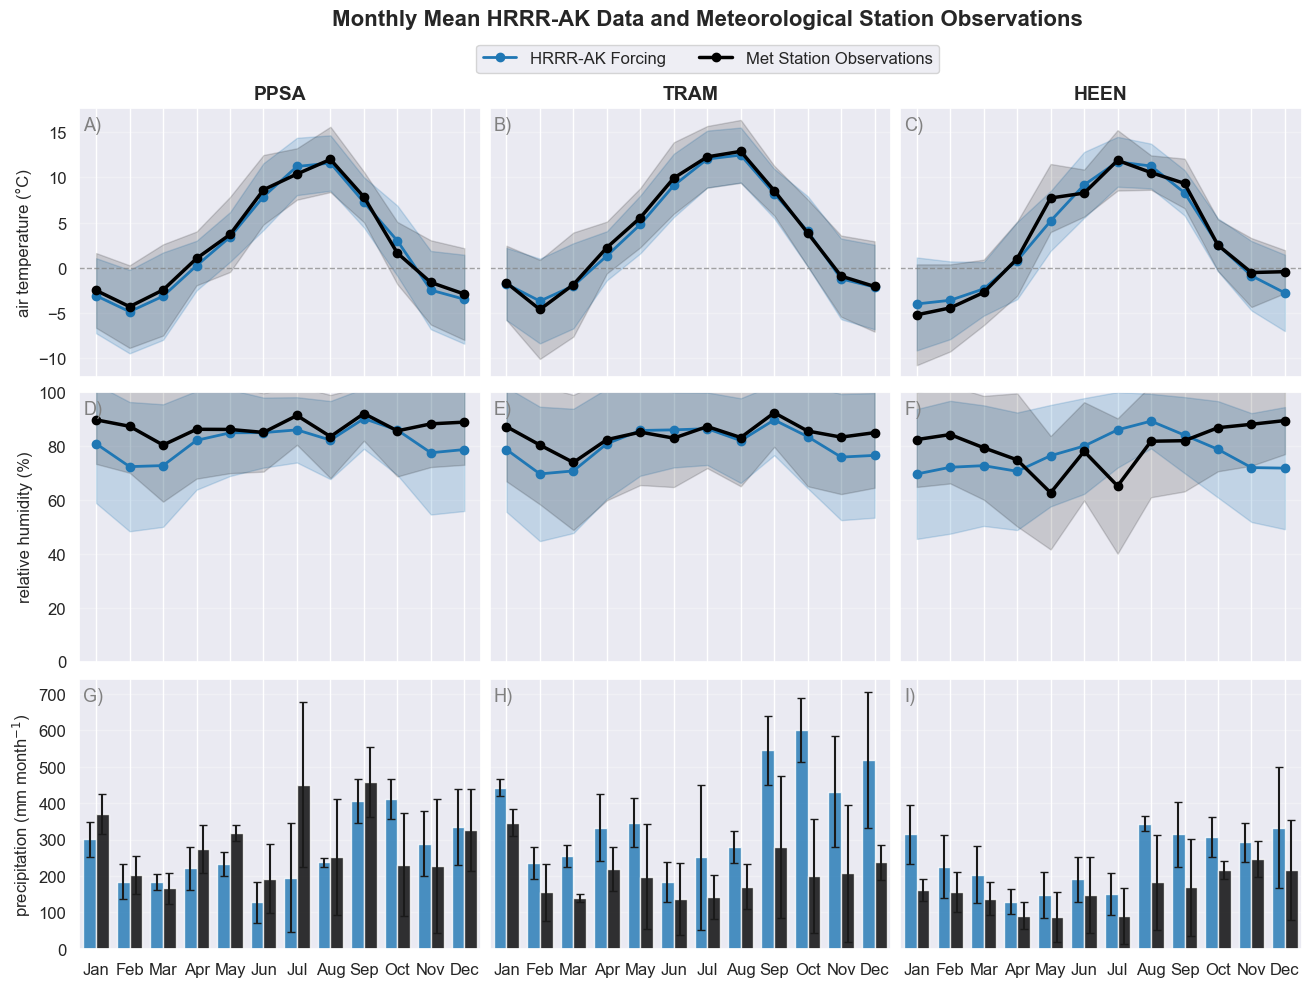

In [11]:
# =============================================================================
# PRECIPITATION DISPLAY OPTION
# =============================================================================

# 'hourly_mean'   = mean hourly precipitation rate for each month
# 'monthly_total' = mean monthly accumulated precipitation climatology

precip_mode = 'monthly_total'
# precip_mode = 'hourly_mean'


import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# USER SETTINGS
# =============================================================================

fontsize = 12

hrrrak_color = 'tab:blue'
obs_color = 'black'

linewidth_hrrr = 2
linewidth_obs = 2.5

alpha_hrrr = 0.20
alpha_obs = 0.15

figsize = (13, 9)


# =============================================================================
# DATASETS
# =============================================================================

hrrr_datasets = {
    'PPSA': ds_hrrr_ppsa,
    'TRAM': ds_hrrr_tram,
    'HEEN': ds_hrrr_heen
}

hrrr_lapserate_datasets = {
    'PPSA': ds_hrrr_lapserate_ppsa,
    'TRAM': ds_hrrr_lapserate_tram,
    'HEEN': ds_hrrr_lapserate_heen
}

obs_datasets = {
    'PPSA': ds_obs_ppsa,
    'TRAM': ds_obs_tram,
    'HEEN': ds_obs_heen
}

site_names = ['PPSA', 'TRAM', 'HEEN']

var_names = [
    'temp',
    'rh',
    'precip_accum_1hr'
]

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

letters = list('ABCDEFGHI')


# =============================================================================
# VARIABLE LABELS
# =============================================================================

if precip_mode == 'monthly_total':
    precip_label = 'precipitation (mm month$^{-1}$)'
else:
    precip_label = 'precipitation (mm hr$^{-1}$)'

var_labels = {
    'temp': 'air temperature (°C)',
    'rh': 'relative humidity (%)',
    'precip_accum_1hr': precip_label
}


# =============================================================================
# FIGURE
# =============================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=figsize,
    sharex=True,
    sharey='row',
    constrained_layout=True
)


# =============================================================================
# LOOP THROUGH SITES AND VARIABLES
# =============================================================================

for col, site in enumerate(site_names):

    ds_hrrr = hrrr_datasets[site]
    ds_hrrr_lapserate = hrrr_lapserate_datasets[site]
    ds_obs = obs_datasets[site]

    for row, var in enumerate(var_names):

        ax = axes[row, col]

        # ---------------------------------------------------------------------
        # Add a 0 °C reference line
        # ---------------------------------------------------------------------

        if var == 'temp':

            ax.axhline(
                0,
                color='gray',
                lw=1,
                ls='--',
                alpha=0.7
            )


        # =====================================================================
        # TEMPERATURE AND RELATIVE HUMIDITY CLIMATOLOGY
        # =====================================================================

        if var != 'precip_accum_1hr':

            # -----------------------------------------------------------------
            # HRRR-AK forcing
            #
            # Temperature:
            #     use lapse-rate-corrected HRRR-AK
            #
            # Relative humidity:
            #     use original HRRR-AK
            # -----------------------------------------------------------------

            if var == 'temp':

                hrrr_mean = (
                    ds_hrrr_lapserate[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    ds_hrrr_lapserate[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

            else:

                hrrr_mean = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )


            # -----------------------------------------------------------------
            # Meteorological station observations
            # -----------------------------------------------------------------

            obs_mean = (
                ds_obs[var]
                .groupby('time.month')
                .mean(skipna=True)
            )

            obs_std = (
                ds_obs[var]
                .groupby('time.month')
                .std(skipna=True)
            )


        # =====================================================================
        # PRECIPITATION CLIMATOLOGY
        # =====================================================================

        else:

            # -----------------------------------------------------------------
            # Mean hourly precipitation rate
            # -----------------------------------------------------------------

            if precip_mode == 'hourly_mean':

                hrrr_mean = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    ds_hrrr[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )

                obs_mean = (
                    ds_obs[var]
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                obs_std = (
                    ds_obs[var]
                    .groupby('time.month')
                    .std(skipna=True)
                )


            # -----------------------------------------------------------------
            # Monthly accumulated precipitation climatology
            # -----------------------------------------------------------------

            elif precip_mode == 'monthly_total':

                # HRRR-AK monthly totals
                hrrr_monthly = (
                    ds_hrrr[var]
                    .resample(time='MS')
                    .sum(skipna=True)
                )

                hrrr_coverage = (
                    ds_hrrr[var]
                    .notnull()
                    .resample(time='MS')
                    .mean()
                )

                hrrr_monthly = hrrr_monthly.where(
                    hrrr_coverage >= 0.90
                )

                hrrr_mean = (
                    hrrr_monthly
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                hrrr_std = (
                    hrrr_monthly
                    .groupby('time.month')
                    .std(skipna=True)
                )


                # Observation monthly totals
                obs_monthly = (
                    ds_obs[var]
                    .resample(time='MS')
                    .sum(skipna=True)
                )

                obs_coverage = (
                    ds_obs[var]
                    .notnull()
                    .resample(time='MS')
                    .mean()
                )

                obs_monthly = obs_monthly.where(
                    obs_coverage >= 0.90
                )

                obs_mean = (
                    obs_monthly
                    .groupby('time.month')
                    .mean(skipna=True)
                )

                obs_std = (
                    obs_monthly
                    .groupby('time.month')
                    .std(skipna=True)
                )

            else:

                raise ValueError(
                    "precip_mode must be "
                    "'hourly_mean' or 'monthly_total'"
                )


        # =====================================================================
        # TEMPERATURE AND RELATIVE HUMIDITY PLOTS
        # =====================================================================

        if var != 'precip_accum_1hr':

            # HRRR-AK uncertainty
            ax.fill_between(
                hrrr_mean.month,
                hrrr_mean - hrrr_std,
                hrrr_mean + hrrr_std,
                color=hrrrak_color,
                alpha=alpha_hrrr
            )

            # Observation uncertainty
            ax.fill_between(
                obs_mean.month,
                obs_mean - obs_std,
                obs_mean + obs_std,
                color=obs_color,
                alpha=alpha_obs
            )

            # HRRR-AK mean
            ax.plot(
                hrrr_mean.month,
                hrrr_mean,
                color=hrrrak_color,
                lw=linewidth_hrrr,
                marker='o',
                label='HRRR-AK Forcing'
            )

            # Observed mean
            ax.plot(
                obs_mean.month,
                obs_mean,
                color=obs_color,
                lw=linewidth_obs,
                marker='o',
                label='Met Station Observations'
            )


        # =====================================================================
        # PRECIPITATION PLOTS
        # =====================================================================

        else:

            months = np.arange(1, 13)
            width = 0.38

            ax.bar(
                months - width / 2,
                hrrr_mean,
                width,
                color=hrrrak_color,
                alpha=0.8,
                yerr=hrrr_std,
                capsize=3,
                label='HRRR-AK Forcing'
            )

            ax.bar(
                months + width / 2,
                obs_mean,
                width,
                color=obs_color,
                alpha=0.8,
                yerr=obs_std,
                capsize=3,
                label='Met Station Observations'
            )


        # =====================================================================
        # AXIS FORMATTING
        # =====================================================================

        ax.set_xlim(0.5, 12.5)

        ax.set_xticks(np.arange(1, 13))
        ax.set_xticklabels(month_labels)

        ax.tick_params(
            axis='both',
            labelsize=fontsize
        )

        ax.grid(
            axis='y',
            alpha=0.3
        )


        # ---------------------------------------------------------------------
        # Panel labels
        # ---------------------------------------------------------------------

        panel_num = row * 3 + col

        ax.text(
            0.01,
            0.97,
            f'{letters[panel_num]})',
            transform=ax.transAxes,
            fontsize=fontsize + 1,
            va='top',
            color='gray'
        )


        # ---------------------------------------------------------------------
        # Row labels
        # ---------------------------------------------------------------------

        if col == 0:

            ax.set_ylabel(
                var_labels[var],
                fontsize=fontsize
            )


        # ---------------------------------------------------------------------
        # Column titles
        # ---------------------------------------------------------------------

        if row == 0:

            ax.set_title(
                site,
                fontsize=fontsize + 2,
                fontweight='bold'
            )


# =============================================================================
# SINGLE LEGEND
# =============================================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    fontsize=fontsize,
    bbox_to_anchor=(0.54, 1.05)
)


# =============================================================================
# AXIS LIMITS
# =============================================================================

axes[1, 0].set_ylim(0, 100)
axes[1, 1].set_ylim(0, 100)
axes[1, 2].set_ylim(0, 100)


# =============================================================================
# FIGURE TITLE
# =============================================================================

plt.suptitle(
    "Monthly Mean HRRR-AK Data and Meteorological Station Observations",
    fontsize=fontsize + 4,
    fontweight='bold',
    x=0.54,
    y=1.08
)


plt.show()